# 02. Neural Network Classification with PyTorch

### Overview & Core Concepts
* **Classification Architecture & Shapes:** Input feature dimensions, hidden representation layers, and output mappings for binary vs. multi-class classification tasks.
* **Logits to Probabilities to Predictions:** Transforming raw model outputs ($\text{logits}$) into probabilities via activation functions ($\text{Sigmoid}$ for binary, $\text{Softmax}$ for multi-class) and mapping to discrete class labels using rounding or $\text{argmax}$.
* **Loss Functions & Numerical Stability:** Cross-entropy mechanics and exponential penalty behavior; using `BCEWithLogitsLoss` over raw `BCELoss(Sigmoid)` to eliminate extreme-value saturation and prevent $\text{NaN}$ numerical instability.
* **Optimizer Dynamics & Trade-offs:** Comparing gradient update mechanics—standard `SGD`, momentum-accelerated descent (`SGD with Momentum`), adaptive per-parameter scaling (`RMSprop`), and hybrid first/second-moment tracking (`Adam`).
* **Non-Linearity & Gradient Dynamics:** Breaking linear decision boundaries via non-linear activations (`nn.ReLU`); mitigating vanishing/exploding gradients using residual connections, batch normalization, gradient clipping, and He/Xavier weight initialization.
* **Comprehensive Evaluation Metrics:** Diagnostic assessment beyond accuracy using Confusion Matrices, Precision, Recall, F1-Score, Classification Reports, and ROC-AUC curve threshold sweeps.

--------
--------

# Neural Network classification in PyTorch

### Classification is a problem of predicting whether something is one thing or another (there can be multiple things as the options)

In [1]:
what_are_we_going_to_cover = {
    1: "Architecture of a Neural Network classification model",
    2: "Input shapes and output shapes of a classification model(features and labels)",
    3: "Creating custom data to view, fit on and predict on",
    4: "Steps in modelling: Creating a model, setting a loss function and optimizer, creating a training loop, evaluating a model",
    5: "Saving and loading models",
    6: "Harnessing the power of non-linearity",
    7: "Different classification evaluation methods"
}

what_are_we_going_to_cover

{1: 'Architecture of a Neural Network classification model',
 2: 'Input shapes and output shapes of a classification model(features and labels)',
 3: 'Creating custom data to view, fit on and predict on',
 4: 'Steps in modelling: Creating a model, setting a loss function and optimizer, creating a training loop, evaluating a model',
 5: 'Saving and loading models',
 6: 'Harnessing the power of non-linearity',
 7: 'Different classification evaluation methods'}

## 1. Make classification data and get it ready

In [2]:
## PyTorch is mostly focused on DeepLearning while Scikit-Learn is more focused on MachineLearning
import sklearn

# scikit-learn is a robust library used for data preprocessing, modelling(like classification, regression, and clustering),
#  and moodel evaluation. It also includes handy tools to generate "fake" datasets so we can test algorithms before 
#  throwing real-world data at them.

In [3]:
from sklearn.datasets import make_circles

# Make 1000 samples(no of samples)
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                   noise=0.03,
                   random_state=42) #random seed

# sklearn.datasets: contains built-in datasets and dataset generators.
# make_circles: It generates a toy dataset shaped like concentric circles. It is perfect for testing algorithms 
#               that need to separate non-linear data.

# X,y = make_circles(n_samples, noise=0.03, random_state=42)
# make_circles return two separate arrays at the same time. The coordinates go into X(our feature), 
#            and the circle identifiers go into y(our target/labels).
# n_samples: tells the make_circles function to make 1000 data points total(500 for outer circle and 500 for inner circle)
# noise = 0.03: Adds a tiny bit of random shale/blur to the data. Without noise, we would get two mathematically perfect, thin lines.
#               Noise makes it look like real-world, slightly messy data.
# random_state = 42: This is random seed. Because the noise is random, setting this to 42(or any integer) ensures that every time we run 
# this code, we get the exact same "random" data. It makes our code reproducible.

In [4]:
len(X), len(y)

(1000, 1000)

In [5]:
print(f"First 5 samples of X:\n{X[:5]}")
print(f"First 5 samples of y:\n {y[:5]}")

First 5 samples of X:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y:
 [1 1 1 1 0]


In [6]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1" : X[:,0],
                        "X2" : X[:,1],
                        "label" : y})
# circles[:10] it also shows the same output (but .head() is specific pandas method and preferred)
circles.head(10) #if left blank it defaults to 5 instead of 10
#.tail(10) is used to view the last 10 rows in the dataset

# circles.[:10] would have given the same result but here .head() is preferred as the former slicing method is almost used everywhere, but 
#    the latter .head() exactly means we want a quick view of the dataset.

# pandas is python library designed entirely for data manipulation and analysis. (excel on steroids kind)
# DataFrama: The primary tool inside Pandas. It is a 2D, tabular data structure with labelled axes(rows and columns). 
#             (same picture as a spreadsheet or a SQL table)
# pd.Dataframe: Calls the Pandas constructor to build a brand new table. Inside the parenthesis we feed it a dictionary where the keys 
#              become column header and the values become the column data.
# X[:,0]: all rows from 1st Dim and take the first column from 2nd Dim
# X[:,1]: all rows from 1st Dim and take the second column from 2nd Dim
# label provides the target values(0 for outer circle, 1 for inner circle)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [7]:
circles.label.value_counts()

# .label(): Its a pandas dot notation .which tells "Ignore the rest of the table and just look at the column named 'label'."
#.valuecounts() looks through all 1000 rows in that specific column and finds every unique case(in this case 0s and 1s) and counts
#     exactly how many times each unique label appears
# Use to check if the dataset is balanced or not(500/500 here but sometimes it may also be 990/10)

label
1    500
0    500
Name: count, dtype: int64

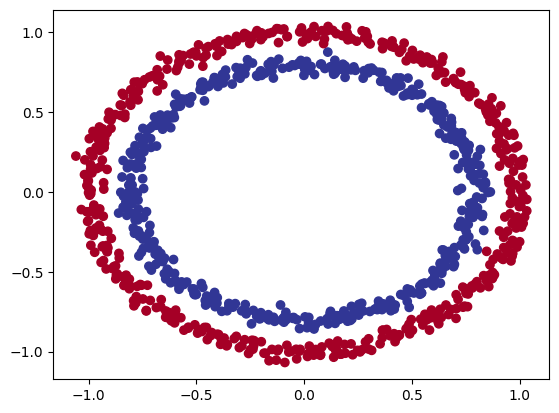

In [8]:
# visuzalize, visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu); #cmap  is the colormap 

# many colors can be given like ['Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds', 'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu', 'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn']

# x = X[:,0](The Horizontal Axis) - represents the X-coordinates of our 1000 points
# y = X[:,1](The Vertical Axis) - represents the Y-coordinates of our 1000 points
# c = y(The Color Secret) - c stands for color. Instead of coloring every single dot same shade, we are passing or our label array.
#     Due to that matplotlib groups the dot into two distinct color groups based on those numbers.
# cmap = plt.cm.RdYlBu
# cmap stands for colormap, If c=y tells Matplotlib how to group colors, cmap tells it which specific colors to use 
# RdYlBu is built-in palette for RedYellowBlue, as we have 2 groups(0 and 1), matplotlib will assign one groupp to the Red end of the 
#      spectrum and the other group to the blue end of the spectrum.

**Note**: The data we're working with is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundamentals.

### 1.1 Check Inputs and Output shapes

In [9]:
X.shape, y.shape

((1000, 2), (1000,))

In [10]:
X,# y

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        ...,
        [-0.13690036, -0.81001183],
        [ 0.67036156, -0.76750154],
        [ 0.28105665,  0.96382443]]),)

In [11]:
# View the first sample of features and labels
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


### 1.2 Turn data into tensors and create train and test splits

In [12]:
import torch
torch.__version__

'2.10.0+cu128'

In [13]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [14]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [15]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [16]:
# Split data into training and test sets(random split we'll do here)
# sklearn.model_selction is a module in scikit-learn provides tools for data splitting, evaluating ML models and performing cross-validation
# function1: train_test_split: split data into training and testing sets

# model_selection have cross validation tools like Kfold, StratifiedKFold, cross_val_score and cross_validate

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size = 0.2, # 20% data into testing and 80% into training
                                                    random_state = 42) # manual_seed
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Building a model

To build a model to classify our blue and red dots, we want to:

1. Setup device agnnostic code so our code will run on an accelerator (GPU) if there is one
2. Construct a model (by subclassing `nn.Module`)
3. Define a loss funcion and optimizer
4. Create a training and test loop

In [17]:
# Import PyTorch and nn
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Now let's create a model that:

1. Subclass `nn.Module` (almost all models in PyTorch subclass `nn.Module`)
2. Create 2 `nn.Linear()` layers that are capable of handling the shapes of our data
3. Defines a `forward()` method that outlines the forward pass(or forward computation) of the model
4. Instantiate an instance of our model class and send it to the target `device`

In [18]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([800, 2]),
 torch.Size([800]),
 torch.Size([200, 2]),
 torch.Size([200]))

In [19]:
# CLASS torch.nn.Linear(in_features, out_features, bias=True)
# It applies linear transformation to the incoming data : y = X * W^T + b
# Parameters:
# in_features: size of each input sample(i.e size of X)
# out_features: size of each output sample(i.e size of y)
# bias: If set to False the layer will not learn an additive bias. Default is True


# nn.Linear is used to create a Linear Layer(also known as Dense Layer or Fully Connected Layer)
# layer = nn.Linear(2,5)
# in_features(2): 2 input features X1, X2
# out_features(5): 5 output features(how many neurons or hidden nodes that we want in this layer)


# out_features cant we scale to 10000?
# there's kind of an upper limit here where result's benefits starts to fade (significant risk of overfitting)

In [20]:
# 1. Construct a model that subclasses nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 2. Create 2 nn.Linear() layers that are capable of handling the shapes of our data
        self.layer_1 = nn.Linear(in_features = 2, out_features = 5) # 5 isnt a fixed no. here it can be anything
        self.layer_2 = nn.Linear(in_features = 5, out_features = 1) # out_features=1 is same size now as y
        # out_features from the previous layer must be in_features for this layer otherwise we'll get shape mismatch errors

    # 3. define a forward() method that outlines the forward pass
    def forward(self, x):
        return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2 -> output
        #goes like x(x goes into layer 1 as input) -> layer_1(layer 1 output goes as input to layer_2) -> layer_2
    
# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [21]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [22]:
model_0.parameters

<bound method Module.parameters of CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)>

In [23]:
# Let's replicate the model above using nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

# Sequential is beneficial for rapid prototyping (quickly add, remove or swap layers) instead of writing layers from stratch, 
#   chaining them hrough forward method etc.
# Sequential mustn't be used when multiple different inputs(both text and image) pass into model and 
#  branching path or skip connections(like data -> layer1 -> layer3 like in ResNets)

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [24]:
model_0.state_dict()
# 0.weight is 2x5 =10 nos(layer_0 i/p* layer_0o/p), then 0.bias =5 nos(layer_0 o/p) , 
# 1.weight = 5 nos.(layer_1 i/p) , 1.bias = 1 no.(layer_1 o/p)

OrderedDict([('0.weight',
              tensor([[-0.5574,  0.0248],
                      [-0.6424, -0.5511],
                      [-0.2315,  0.3932],
                      [-0.3784, -0.5854],
                      [-0.6055,  0.5577]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6206,  0.3872, -0.5590, -0.4676, -0.0786], device='cuda:0')),
             ('1.weight',
              tensor([[-0.3193,  0.3264, -0.1287,  0.2113, -0.4094]], device='cuda:0')),
             ('1.bias', tensor([0.2169], device='cuda:0'))])

In [25]:
# Make some predictions
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions:\n{torch.round(untrained_preds[:10])}") # these untrained_preds suppose to match y_test
print(f"\nFirst 10 labels:\n{y_test[:10]}")

#torch.round rounds it to nearest integer but half are round to even like 2.5,4.5 will round to 2,4

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
tensor([[0.],
        [-0.],
        [1.],
        [-0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [-0.]], device='cuda:0')

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [26]:
X_test[:10], y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 Setup loss function and optimizer

Which loss function or oprimizer should we use? Again... this is problem specific.

- For example, for regression we might want MAE or MSE (mean absolute error or mean squared error).
  MSE if we want to highly penalize outliers and MAE if we want to take into account of the noise(in case of more noisy dataset use MAE).
- For classification we might want binary cross entropy or categorical cross entropy (cross entropy).

* Loss function measures how *wrong* our model's predictions are.

Cross Entropy is a loss function whose job is to count how wrong our model is.
It works on a Confident Penalty System:
- If model 100% confident, loss=0
- If model slightly wrong, moderate penalty
- If model is confidently wrong(like 99% sure a dot is 1 while its 0), it gets a massive exponential huge penalty.

`BCE(Binary Cross Entropy)` - Used when 2 categories, Sigmoid Activation function

`Cross Entropy(Categorical Cross Entropy)` - Used when multiple categories, Softmax Activation function
$$ \text{BCE} = - \left( y \log(p) + (1 - y) \log(1 - p) \right) $$

$$ \text{Cross Entropy} = - \sum_{i=1}^{C} y_i \log(p_i) $$

BCEWithLogitsLoss: when data passes through nn.Linear() a number is spit out like 4.2, 29.4 etc. But BCE requires percentages(probabilities between 0 and 1) so using sigmoid function to squish the numebers between 0 and 1.

The problem with BCELoss(Sigmoid(Logits)) is sigmoid can scale -1000 to 0(very close to 0 like 0.00000000000001 and computer rounds it to 0). and log(0) is $-\infty$ which gives NaN so BCEWithLogitsLoss fixes it using clever tricks to avoid NaN explosion.


Sigmoid: (Total sum of probabilities may exceed 1) - $$ \sigma(x) = \frac{1}{1 + e^{-x}} $$ 

Softmax(The Shared Equation): (Total sum of probabilities is exactly  1) - $$ \text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{K} e^{x_j}} $$ 


- `Logits`: Logits in DL, the logits layer is the layer that feeds into softmax(or other such normalization). The output of the softmax are the probabilities for the classification tasks and its input is the logits layer. Logits range($-\infty$, $-\infty$) while softmax range transform to (0,1)

-----

## Optimizers

1. `SGD(Stoicastic Gradient Descent)`: 
- Mechanism: Updates network Weights in the exact opposite direction of the gradient of the loss function.
- Update Rule: $\theta_{t+1} = \theta_t - \eta \nabla L_t$ (where $\eta$ is the learning rate and $\nabla L_t$ is the gradient).
- Characteristics: Applies a fixed, uniform learning rate to all parameters globally.
- Technical Flaw: Prone to severe osicallations in areas of high curvature(ravines - ravines refer to narrow, steep valleys in the loss function surface where the gradient changes rapidly in one dimension but slowly in another. SGD struggles in these areas) and frequently stalls when gradient approach zero at local minima(get stuck at local minima unable to find global minima) or saddle points.

2. `SGD with Momentum`: 
- Mechanism: Accelerates SGD by incorporating an exponentially weighted moving average of past gradients(the first moment).
- Update Rule: Introduces a velocity vector $v_t = \gamma v_{t-1} + \eta \nabla L_t$, where $\gamma$ is the momentum coefficient.
- Technical Benefit: Accelerates convergernce along dimensions where the gradient consistently points in the same direction, while dampening oscillations where the gradient frequently changes direction.

3. `RMSprop(Root Mean Square Propagation)`:
- Mechanism: Introduces an **adative learning rate** evaluated individually for every single weight in the network.
- Characteristics: Maintains a moving average of the squared gradients(the second moment). It then divides the global learning rate by the square root of this moving average.
- Technical Benefit: Automatically scales down the step size for weights with highly volatile/large gradients(preventing divergence) and scales up the step size for weights with tiny gradients (preventing stagnation).

4. `Adam(Adaptive Moment Collision`:
- Mechanism: A hybrid algorithm that computes individual adaptive learing rates by combining the heuristics of both Momentum and RMSprop.
- Characteristics: Keeps an exponentially decayiing average of both past gradients (first moment, $m_t$) and past squared gradients (second moment, $v_t$). It also applies a *bias-correction* step during the initial early iterations to prevent the moment estimates from skewing towards zero.
- Technical Benefit: Highly robust to noisy data, sparse gradients, and complex loss landscapes. It requires very little hyperparameter tuning, making it the industry standard for initializing neural network trianing. 


| Optimizer | Analogy              | Best Feature                              | Flaw                                        |
|-----------|----------------------|-------------------------------------------|---------------------------------------------|
| SGD       | Blindfolded Hiker    | Simple, takes steps strictly downhill     | Slow, gets stuck in small potholes easily   |
| Momentum  | Heavy Bowling Ball   | Builds speed to blast through potholes    | Can build too much speed and overshoot      |
| RMSprop   | Smart Suspension     | Smooths out violent side-to-side bouncing | Doesn't build forward momentum well         |
| Adam      | Smart Bowling Ball   | Combines Momentum and RMSprop             | The industry standard default               |


| Loss function/Optimizer                     | Problem type	                         | PyTorch Code                              |
|---------------------------------------------|------------------------------------------|-------------------------------------------|
| Stochastic Gradient Descent(SGD) optimizer  | Classification, regression, many others. | `torch.optim.SGD()`                       |
| Adam Optimizer                              | Classification, regression, many others. | `torch.optim.Adam()`                      |
| Binary cross entropy loss	                  | Binary classification	                 | `torch.nn.BCELossWithLogits or torch.nn.BCELoss` |
| Cross entropy loss	                      | Multi-class classification	             | `torch.nn.CrossEntropyLoss`               |
| Mean absolute error (MAE) or L1 Loss	      | Regression	                             | `torch.nn.L1Loss`                         | 
| Mean squared error (MSE) or L2 Loss	      | Regression	                             | `torch.nn.MSELoss`                        | 

- `torch.nn.BCELoss()`: Creates a loss function that measures the binary cross entropy between the target(label) and input(features).
- `torch.nn.BCELossWithLogitsLoss()`: This is the same as above except it has a sigmoid layer(nn.Sigmoid) built-in.
- `torch.nn.Softmax()`: This is the same as above except it has a softmax layer(Rescales them so that the elements of the n-dimensional output Tensor lie in the range [0,1] and sum to 1) instead of sigmoid.

In [27]:
#  Setup the loss function
# loss_fn = nn.BCELoss() # BCELoss requires inputs to have gone through the sigmoid activation function prior to input to BCELoss
# like nn.Sequential(
#     nn.Sigmoid(),
#     nn.BCELoss()
# )

loss_fn = nn.BCEWithLogitsLoss() # sigmoid activation function built-in

optimizer = torch.optim.SGD(params = model_0.parameters(),
                           lr = 0.1)

In [28]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.5574,  0.0248],
                      [-0.6424, -0.5511],
                      [-0.2315,  0.3932],
                      [-0.3784, -0.5854],
                      [-0.6055,  0.5577]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6206,  0.3872, -0.5590, -0.4676, -0.0786], device='cuda:0')),
             ('1.weight',
              tensor([[-0.3193,  0.3264, -0.1287,  0.2113, -0.4094]], device='cuda:0')),
             ('1.bias', tensor([0.2169], device='cuda:0'))])

In [29]:
# Calculate accuracy - out of 100 examples, what percentage does our model get right?
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() #torch.eq checks if both parameters are equal 
    acc = (correct/len(y_pred)) * 100
    return acc

# torch.eq() doesnt outputs numbers but boolean values like tensor([True, False, True, False])
# .sum does 1+0+1+0 = 3. output=3(1=True and 0=False) 
#.item() is used to extract actual numerical value from tensor

---

## 3. Train Model

To train our model, we're going to need a training loop with the following steps:

1. Forward Pass
2. Calculate the loss
3. Optimizer Zero Grad
4. Loss Backward(backpropagation)
5. Optimizer Step(Gradient descent)

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw **logits**.

We can convert these **logits** into **prediction probabilities** by passing them to some kind of activation function(e.g. sigmoid for binary classification and softmax for multiclass classification).

Then we can convert our model's prediction probabilities to **prediction labels** by rounding them(binary) or taking the `argmax()`(multiclass).

In [30]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[ 0.0814],
        [-0.0176],
        [ 0.6159],
        [-0.0712],
        [ 1.0526]], device='cuda:0')

In [31]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [32]:
# Use the sigmoid activation function on our model logits to turn them into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5203],
        [0.4956],
        [0.6493],
        [0.4822],
        [0.7413]], device='cuda:0')

For our prediction probability values, we need to perform a range-style rounding on them:
- `y_preds_probs` >= 0.5, `y=1`(Class 1)
- `y_preds_probs` <0.5, `y=0` (Class 0)

* We can create our own custom function to change the threshold of 0.5 to 0.7, 0.8 or anything we like.

In [33]:
torch.round(y_pred_probs)

tensor([[1.],
        [0.],
        [1.],
        [0.],
        [1.]], device='cuda:0')

In [34]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)

# In full(logits -> pred probs -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
print(f"y_preds: {y_preds.squeeze()} \n vs \ny_test: {y_test[:5]}")

tensor([True, True, True, True, True], device='cuda:0')
y_preds: tensor([1., 0., 1., 0., 1.], device='cuda:0') 
 vs 
y_test: tensor([1., 0., 1., 0., 1.])


In [35]:
!nvidia-smi

Sun May 24 16:03:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             28W /   70W |     153MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### 3.2 Building a training and testing loop

In [36]:
loss_fn #BCEWithLogitsLoss expects logits as input parameter

BCEWithLogitsLoss()

In [37]:
loss_fn_without_logits = nn.BCELoss()
loss_fn_without_logits #BCELoss expects prediction probabilites as input parameter

BCELoss()

In [38]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put the data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Building training and evaluation loop
for epoch in range(epochs):
    # Training
    model_0.train()

    # 1. Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels

    # 2. Calculate loss/accuracy(testing loss/accuracy)
    # loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss expects prediction probabilities as input
    #               y_train)
    loss = loss_fn(y_logits, # nn.BCEWithLogitsLoss expects raw logits as input
                  y_train)
    acc = accuracy_fn(y_true = y_train, 
                     y_pred = y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()
    
    # 4. Loss Backward (Backpropagation)
    loss.backward()
    
    # 5. Optimizer step (Gradient Descent)
    optimizer.step()

    ##Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward Pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss/accuracy
        test_loss = loss_fn(test_logits, #BCEWithLogitsLoss
                            y_test)
        test_acc = accuracy_fn(y_true = y_test,
                              y_pred = test_pred)

    # Print out what's happening 
    if epoch%10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test accuracy: {test_acc:.2f}")

Epoch: 0 | Loss: 0.75204, Accuracy: 57.00% | Test loss: 0.72721, Test accuracy: 60.00
Epoch: 10 | Loss: 0.71874, Accuracy: 52.75% | Test loss: 0.70288, Test accuracy: 52.50
Epoch: 20 | Loss: 0.70725, Accuracy: 51.00% | Test loss: 0.69551, Test accuracy: 52.00
Epoch: 30 | Loss: 0.70245, Accuracy: 50.38% | Test loss: 0.69306, Test accuracy: 52.50
Epoch: 40 | Loss: 0.69996, Accuracy: 49.62% | Test loss: 0.69216, Test accuracy: 53.00
Epoch: 50 | Loss: 0.69841, Accuracy: 49.88% | Test loss: 0.69180, Test accuracy: 53.00
Epoch: 60 | Loss: 0.69732, Accuracy: 49.50% | Test loss: 0.69166, Test accuracy: 51.00
Epoch: 70 | Loss: 0.69650, Accuracy: 49.62% | Test loss: 0.69164, Test accuracy: 52.50
Epoch: 80 | Loss: 0.69586, Accuracy: 49.50% | Test loss: 0.69168, Test accuracy: 52.50
Epoch: 90 | Loss: 0.69535, Accuracy: 49.25% | Test loss: 0.69177, Test accuracy: 52.50


## 4. Making predictions and evaluate the model

From the metrics it looks like our model isn't learning anything...

So to inspect it let's make some predictions and make them visual!

To do so we're going to import a function called `plot_decision_boundary()`

In [39]:
# def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
#     """Plots decision boundaries of model predicting on X in comparison to y"""

#     # Put everything to CPU (works better with NumPy + Matplotlib)
#     model.to("cpu")
#     X, y = X.to("cpu"), y.to("cpu")

#     # Setup prediction boundaries and grid
#     x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
#     y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
#     xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
#                          np.linspace(y_min, y_max, 101))

#     # Make features
#     X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

#     # Make Predictions
#     model.eval()
#     with torch.inference_mode():
#         y_logits = model(X_to_pred_on)

#     # Test for multi-class or binary and adjust logits to prediction labels
#     if len(torch.unique(y)) > 2:
#         y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # multi-class
#     else:
#         y_pred = torch.round(torch.sigmoid(y_logits)) # binary

#     # Reshape preds and plot
#     y_pred = y_pred.reshape(xx.shape).detach().numpy()
#     plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
#     plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
#     plt.xlim(xx.min(), xx.max())
#     plt.ylim(yy.min(), yy.max())





#1. Function defintion: 
# This is a classic Helper Function to visualize how well a neural network has learned to separate different classes of data.
# def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y:torch.Tensor): The function expects a trained PyTorch Neural Network,
#                the input features(for 2d plot its usually a tensor with 2 columns representing x and y coordinates on a graph),
#             and the true labels for those data points(e.g. 0 for red dot and 1 for blue dot)
# model.to("cpu"), X.to("cpu"), y.to("cpu"): sending the data to cpu as if we train the model on a GPU, the tensors live in the GPUs memory.
# NumPy and Matplotlib cant read GPU memory so we move the model and data to cpu.

#2. Building the prediciton grid:
# The core idea of a decision boundary plot is to create a massive grid of thousands of tiny invisible dots covering the whole graph,
#    ask the model to predict the color of every single dot, and then color the background based on those predictions.
# x_min, x_max = X[:,0].min() - 0.1, X[:,0].max() + 0.1
# x_min, x_max = X[:,1].min() - 0.1, X[:,1].max() + 0.1
# Find the lowest and highest values of our data so we know how big to draw the graph. The -0.1 and +0.1 are padding added so that around 
#     the edges the data points shouldn't get cutoff.
#
# xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
#                     np.linspace(y_min, y_max, 101))
# np.linspace(linear space): It generates 101 evenly spaced numbers between our minimum and maximum values.
# np.meshgrid(...): This takes our horizontal row of 101 numbers and our vertical column of 101 numbers and crosses them together. It outputs
# two 2D matrices(xx and yy) that represent the coordinates of an invisible 101x101 grid(10,201 total points).

#3. Formatting the Grid for the model:
# X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()
#
# .ravel(): Flattens the 2D matrix into a 1D list(it returns a view and doesnt make a copy unless memory is non-contiguous unlike .flatten(), 
#           so changes in this records same changes in original location)
# np.column_stack(): Takes the falttened x-coordinates and flattened y-coordinates and zips them together into pairs. We have now 10201 pairs
#                   of (x,y) coordinates.
# torch.from_numpy(...): converts this NumPy array back into a PyTorch tensor.
# .float(): Ensures the data type is float32, which is PyTorch's default.

#4. Making Predictions
# model.eval()
# with torch.inference_mode():
#     y_logits = model(X_to_pred_on)
#
# y_logits = model(X_to_pred_on): we pass our 10201 grid points into the model. The model outputs logits - raw, unnormalized numebrs that
#           havent been converted into probabilities or final class labels yet.

#5.Converting Logits to Final Labels
# if len(torch.unique(y)) > 2:
#         y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # multi-class
#     else:
#         y_pred = torch.round(torch.sigmoid(y_logits)) # binary
#
# len(torch.unique(y)>2): checks how many unique classes present in true labels. If its >2 then multi-class classification(softmax 
#                        activation) and if 2 then binary classification (sigmoid activation)
# .argmax(dim=1): Looks at the probabilities for each point and picks index of the highest one(e.g. Class 2: 90% probability, prediction:2)
# torch.round: rounds anything above 0.5 rounds to 1 and below 0.5 rounds to 0.

#6.Drawing the plot
#  y_pred = y_pred.reshape(xx.shape).detach().numpy()
#  plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
#  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
#  plt.xlim(xx.min(), xx.max())
#  plt.ylim(yy.min(), yy.max())
#
# y_pred = y_pred.reshape(xx.shape).detach().numpy:
# reshape(xx.shape): Takes our 10201 flat predictions and shapes them back into 101x101 2D grid we created earlier.
# .detach().numpy(): Removes the tensor from PyTorch's computational graph and converts it back into a NumPy array so Matplotlib can read it.
# 
# plt.contourf(xx,yy,y_pred,cmap=plt.cm.RdYlBu,alpha=0.7):
# plt.contour: Draws the decision boundary. Because y_pred contains distinct regions of 0s,1s,etc. this function draws lines where the 
#              predictions switch from one class to another
# plt.contourf: It is often used in place of contour to fill the areas with color rather than just drawing the borders.
# cmap=plt.cm.RdYlBu: Uses a Red-Yellow-Blue color map.
# alpha=0.7: Makes the booundary 70% opaque(slightly tansparent)
#
# plt.scatter(X:[:,0], X[:,1], c=y, s=40, cmap=plt.cm.RdYlBu)
# plt.scatter(..): plots the actual, original data points on top of boundary
# X:[:,0], X[:,1] - x and y coordinates
# c=y: Color the dots based on their true labels(y)
# s=40: size of colored dot
#
# plt.xlim(xx.min(), xx.max())
# plt.ylim(yy.min(), yy.max())
# xlim/ylim: Locks the camera view of the graph to the exact edges of the grid we generated, ensuring a clean, tight visual.


# Contour plots are usually used to represent 3D surfaces on flat 2D plane.(remember adam optimizer example)

In [40]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo(if its not already downloaded)
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

# requests.get(..): It tells Python to go to the specific URL and fetch the raw text of code file. The result is stored in a response object.
# with open(..., "wb") as f: It opens the local file named "helper_functions.py", 
#                  the "wb" stands for write binary, Writing in binary is safe default for web downloads because it writes the raw incoming
#                  bytes directly into disk without trying to manipulate strings.
# with is a context manager. It ensures the file is safely closed automatically once the code inside it finishes running, preventing memory 
#    leaks or file corruption
# f.write(request.content): Takes the raw byte content(.content) downloaded from GitHub and writes it directly into your new local file.

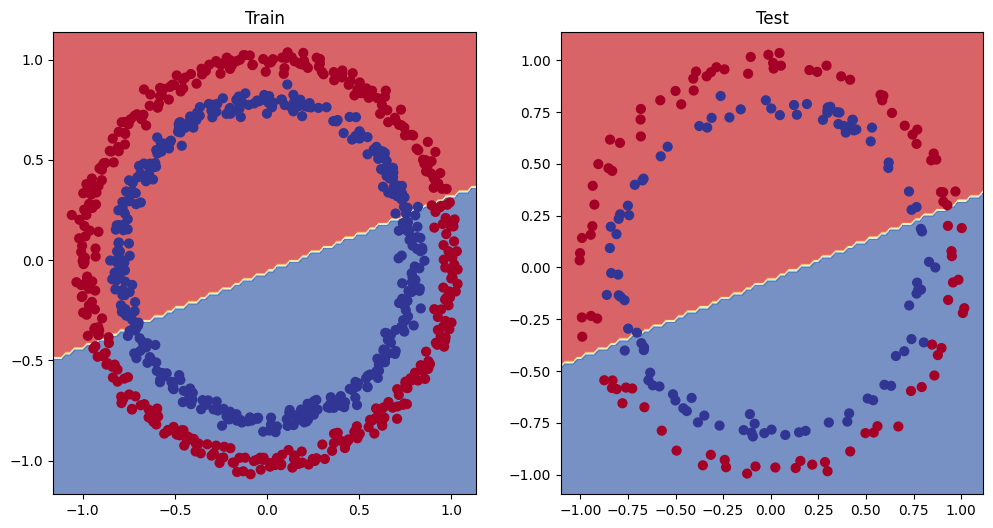

In [41]:
# Plot decision boundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1) #no. of rows, no.of columns, index(which specific slot you want to show in this plot)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

# (12,6) is separated into a gris of 1x2
# plt.subplot() used to create a grid of multiple smaller plots(called "subplots" or "axes") inside a single, larger figure window.
# Instead of showing training and testing results in two separate pop-up windows,subplot lets us place them side-by-side for easy comparison.

## 5. Improving a model (from a model perspective)

* Add more layers - give the model more chances to learn about the patterns in the data
* Add more hidden units - go from 5 hidden units to 10 hidden units
* Fit for longer(run more epochs)
* Changing the activation functions
* Change the learning rate
* Change the loss function

These options are all from a model's perspective because they deal directly with the model, rather than the data(improving amount of data).

And because these options are all values we (as machine learining engineers and data scientists) can change, they are referred to as `hyperparameters`.

Let's try and improve our model by:

(Here we're doing all the changes at once but we need to tune these hyperparameters one-by-one in real-world problems to exactly know changing which hyperparameter refines the model to perform i.e called experiment tracking)

* Adding more hidden units: 5 -> 10
* Increase the number of layers: 2 -> 3
* Increase the number of epochs: 100 -> 1000

###### (too high-exploding gradient, too less-vanishing gradient)

In [42]:
# changing hyperparameters of our model
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        # increasing number of layers 
        self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer_2 = nn.Linear(in_features = 10, out_features = 10) # increasing number of hidden units
        self.layer_3 = nn.Linear(in_features = 10, out_features = 1)

    def forward(self, x):
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        return self.layer_3(self.layer_2(self.layer_1(x))) # this is faster in Pytorch as its a single step
        # this way of writing operations leverages speed ups where possible behind the scenes.

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [43]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.5460, -0.0496],
                      [-0.6530, -0.4819],
                      [-0.2330,  0.4069],
                      [-0.3892, -0.5125],
                      [-0.5895,  0.4521]])),
             ('0.bias', tensor([-0.5681,  0.3329, -0.5502, -0.5144, -0.0037])),
             ('1.weight',
              tensor([[-0.1716,  0.1022,  0.1403,  0.1375, -0.1897]])),
             ('1.bias', tensor([0.0075]))])

In [44]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.122

In [45]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params = model_1.parameters(),
                           lr = 0.1)

In [46]:
# Write a traning and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train for longer
epochs = 1000

# Put data on the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ## Training 
    model_1.train()

    #1. Forward pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> pred probabilities -> prediction llabels

    #2. Calculate the loss/acc
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true = y_train,
                     y_pred = y_pred)
    
    #3. Optimizer zero grad
    optimizer.zero_grad()

    #4. Loss Backward(Backpropagation)
    loss.backward()

    #5. Optimizer Step(Gradient Descent)
    optimizer.step()

    ##Testing
    model_1.eval()
    with torch.inference_mode():
        #1. Forward pass
        test_logits = model_1(X_test).squeeze() #if squeeze not applied then dimension misatch
        test_pred = torch.round(torch.sigmoid(test_logits))

        #2. Test loss/acc
        test_loss = loss_fn(test_logits, y_test)
        acc = accuracy_fn(y_true = y_test,
                         y_pred = test_pred)

    ## print out what's happening
    if epoch%10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test accuracy: {test_acc:.2f}")

Epoch: 0 | Loss: 0.69396, Accuracy: 51.00% | Test loss: 0.69261, Test accuracy: 52.00
Epoch: 10 | Loss: 0.69369, Accuracy: 50.00% | Test loss: 0.69270, Test accuracy: 52.00
Epoch: 20 | Loss: 0.69351, Accuracy: 49.50% | Test loss: 0.69283, Test accuracy: 52.00
Epoch: 30 | Loss: 0.69339, Accuracy: 48.00% | Test loss: 0.69297, Test accuracy: 52.00
Epoch: 40 | Loss: 0.69329, Accuracy: 49.00% | Test loss: 0.69310, Test accuracy: 52.00
Epoch: 50 | Loss: 0.69322, Accuracy: 50.00% | Test loss: 0.69324, Test accuracy: 52.00
Epoch: 60 | Loss: 0.69317, Accuracy: 51.50% | Test loss: 0.69336, Test accuracy: 52.00
Epoch: 70 | Loss: 0.69312, Accuracy: 50.50% | Test loss: 0.69348, Test accuracy: 52.00
Epoch: 80 | Loss: 0.69309, Accuracy: 50.00% | Test loss: 0.69359, Test accuracy: 52.00
Epoch: 90 | Loss: 0.69307, Accuracy: 48.50% | Test loss: 0.69370, Test accuracy: 52.00
Epoch: 100 | Loss: 0.69305, Accuracy: 48.00% | Test loss: 0.69379, Test accuracy: 52.00
Epoch: 110 | Loss: 0.69303, Accuracy: 46.50

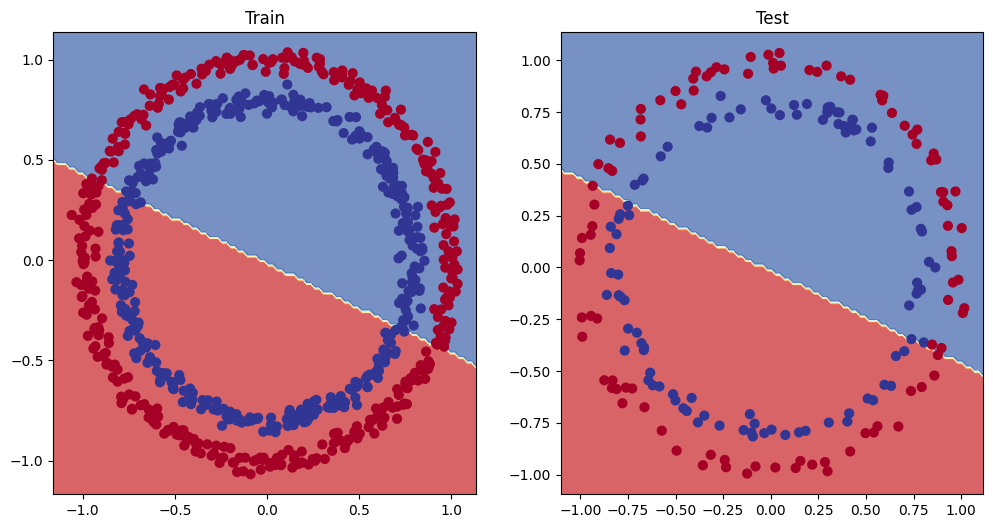

In [47]:
# Plot the decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### 5.1 Creating a Straight line Dataset to see if our model is Learning Anything

One way to troubleshoot a larger problem is to test it out a smaller problem.

In [48]:
# Create some data (same as notebook 1)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias #Linear regression formula(without epsilon)

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [49]:
# Create train and test split
train_split = int(0.8*len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression)

(80, 80, 20, 20)

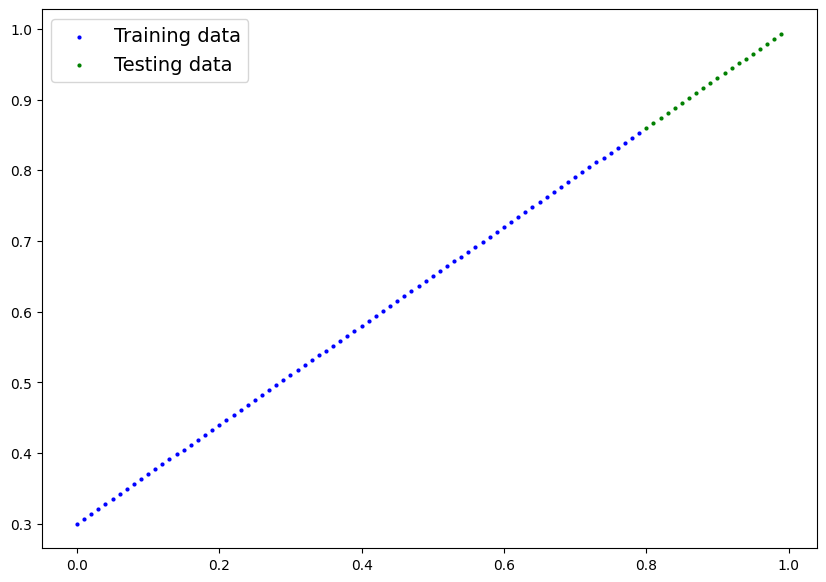

In [50]:
plot_predictions(train_data = X_train_regression,
                train_labels = y_train_regression,
                test_data = X_test_regression,
                test_labels = y_test_regression,
                predictions = None)

In [51]:
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

### 5.2 Adjusting `model_1` to fit a straight line

In [52]:
# Same architecture as model_1 (but using nn.Sequential())
model_2 = nn.Sequential(
    nn.Linear(in_features = 1, out_features = 10),
    nn.Linear(in_features = 10, out_features = 10),
    nn.Linear(in_features = 10, out_features = 1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [53]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model_2.parameters(),
                           lr = 0.01)

In [54]:
# Train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put the data on the target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)


for epoch in range(epochs):
    ## Training 
    model_2.train()

    #1. Forward Pass
    y_pred_regression = model_2(X_train_regression)

    #2. Calculate the loss/acc
    loss = loss_fn(y_pred_regression, y_train_regression)
    # acc = accuracy_fn(y_true = y_train_regression,
    #                  y_pred = y_pred_regression)
    
    #3. Optimizer zero grad
    optimizer.zero_grad()

    #4. Loss Backward(Backpropagation)
    loss.backward()

    #5. Optimizer Step
    optimizer.step()

    ##Testing
    model_2.eval()
    with torch.inference_mode():
        #1. Forward Pass
        test_pred_regression = model_2(X_test_regression)

        #2. Calculate the test loss/acc
        test_loss = loss_fn(test_pred_regression, y_test_regression)
        # test_acc = accuracy_fn(y_true = y_test_regression,
        #                       y_pred = test_pred_regression)

    ## Print out what's happening
    if epoch%100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f}")


# In PyTorch a typical accuracy_fn works by checking if the predicted label exactly matches the true label and in regression due to
# continuous decimal numbers its impossible so accuracy will be zero(like prediction:42.2343, true_label=42.0000, not exactly equal so acc=0)

Epoch: 0 | Loss: 0.75986 | Test loss: 0.91103
Epoch: 100 | Loss: 0.02858 | Test loss: 0.00081
Epoch: 200 | Loss: 0.02533 | Test loss: 0.00209
Epoch: 300 | Loss: 0.02137 | Test loss: 0.00305
Epoch: 400 | Loss: 0.01964 | Test loss: 0.00341
Epoch: 500 | Loss: 0.01940 | Test loss: 0.00387
Epoch: 600 | Loss: 0.01903 | Test loss: 0.00379
Epoch: 700 | Loss: 0.01878 | Test loss: 0.00381
Epoch: 800 | Loss: 0.01840 | Test loss: 0.00329
Epoch: 900 | Loss: 0.01798 | Test loss: 0.00360


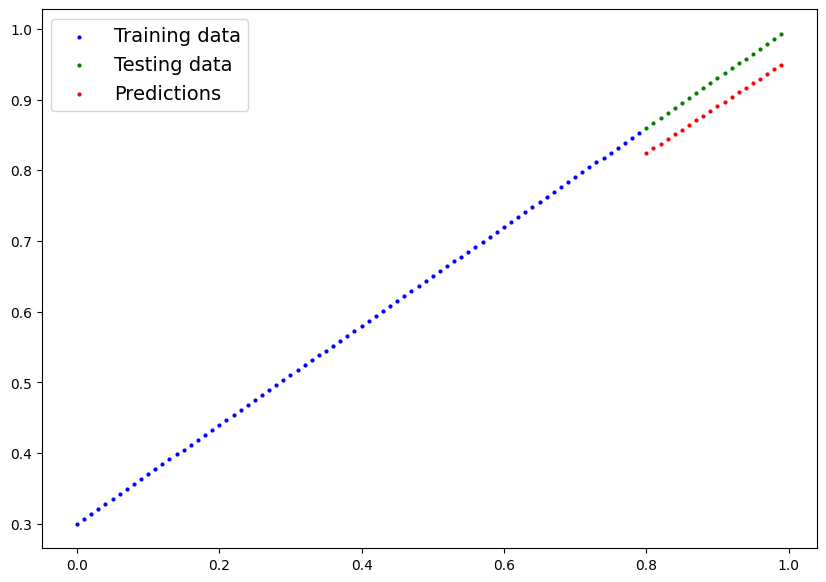

In [55]:
# Turn on evaluation mode
model_2.eval()

# Make predictions(inference)
with torch.inference_mode():
    y_preds_regression = model_2(X_test_regression)

# Plot data and predictions(plot_prediction uses numpy)
plot_predictions(train_data = X_train_regression.cpu(),
                 train_labels = y_train_regression.cpu(),
                 test_data = X_test_regression.cpu(),
                 test_labels = y_test_regression.cpu(),
                 predictions = y_preds_regression.cpu())

---

## 6. The missing piece: non-linearity

"What patterns you could draw if you we're given an infinite amount of straight and non-straight lines?"

Or in machine learning terms, an infinite (but really its finite) of linear and non-linear functions?

### 6.1 Recreating non-linear data(red and blue circles)

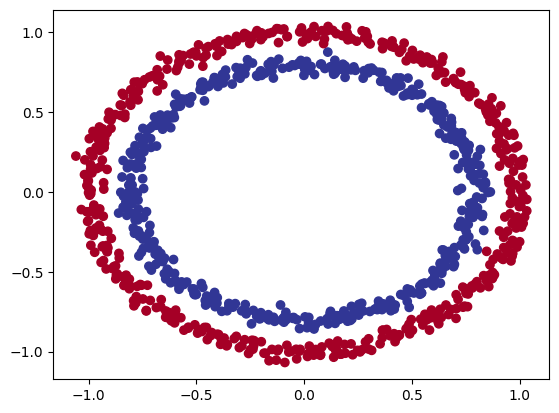

In [56]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                   noise = 0.03,
                   random_state = 42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

In [57]:
# Convert data to tensors and then to train and test splits
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state = 42)
X_train[:5], y_train[:5], 

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [58]:
X_test[:5], y_test[:5], len(y_test)

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438]]),
 tensor([1., 0., 1., 0., 1.]),
 200)

### 6.2 Building a model with non-linearity

- Artificial neural networks are a large combination of linear (straight) and non-straight (non-linear) functions which are potentially able to find patterns in data.

In [59]:
# Build a model with non-linear 
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
        self.relu = nn.ReLU() # ReLU - stands for Rectified Linear Unit(non-linear activation function)

    def forward(self, x):
        # Where should we put our non-Linear activation function?(in between every layer)
        return self.layer_3(self.relu((self.layer_2(self.relu(self.layer_1(x))))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [60]:
# Loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model_3.parameters(), 
                          lr = 0.01)
# optimizer = torch.optim.SGD(params = model_3.parameters(), lr = 0.1) #adam gives much better results so gonna use that

In [61]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [62]:
# Train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the no. of epochs
epochs = 200

# Put the data on the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ## Training
    model_3.train()

    #1. Forward pass
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    #2. Calculate loss/acc
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true = y_train, y_pred = y_pred)
    #3. Optimizer zero grad
    optimizer.zero_grad()
    #4. Loss Backward
    loss.backward()
    #5. Optimizer Step
    optimizer.step()

    ##Testing
    model_3.eval()
    with torch.inference_mode():
        #1. Forward Pass
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        #2. Calculate Loss
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true = y_test, y_pred = test_pred)

    # print out what's happening
    if epoch%10 == 0:
        print(f"Epoch: {epoch} | loss: {loss:.4f}, acc: {acc:.2f}% | test_loss: {test_loss:.4f}, test_acc: {test_acc:.2f}%")
        

Epoch: 0 | loss: 0.6929, acc: 50.00% | test_loss: 0.6920, test_acc: 55.50%
Epoch: 10 | loss: 0.6865, acc: 53.00% | test_loss: 0.6840, test_acc: 56.50%
Epoch: 20 | loss: 0.6770, acc: 53.50% | test_loss: 0.6715, test_acc: 57.00%
Epoch: 30 | loss: 0.6608, acc: 60.75% | test_loss: 0.6530, test_acc: 62.00%
Epoch: 40 | loss: 0.6324, acc: 66.88% | test_loss: 0.6234, test_acc: 70.00%
Epoch: 50 | loss: 0.5851, acc: 74.25% | test_loss: 0.5770, test_acc: 76.50%
Epoch: 60 | loss: 0.5204, acc: 81.50% | test_loss: 0.5294, test_acc: 81.00%
Epoch: 70 | loss: 0.4358, acc: 90.75% | test_loss: 0.4549, test_acc: 89.00%
Epoch: 80 | loss: 0.3395, acc: 96.50% | test_loss: 0.3586, test_acc: 95.50%
Epoch: 90 | loss: 0.2477, acc: 98.50% | test_loss: 0.2724, test_acc: 97.00%
Epoch: 100 | loss: 0.1733, acc: 99.62% | test_loss: 0.2068, test_acc: 99.00%
Epoch: 110 | loss: 0.1211, acc: 99.88% | test_loss: 0.1501, test_acc: 100.00%
Epoch: 120 | loss: 0.0853, acc: 99.88% | test_loss: 0.1124, test_acc: 99.50%
Epoch: 13

### 6.4 Evaluating a model trained with non-linear activation functions

In [63]:
X_test.device, y_preds.device, y_test.device

(device(type='cuda', index=0),
 device(type='cuda', index=0),
 device(type='cuda', index=0))

In [64]:
# make predictions
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

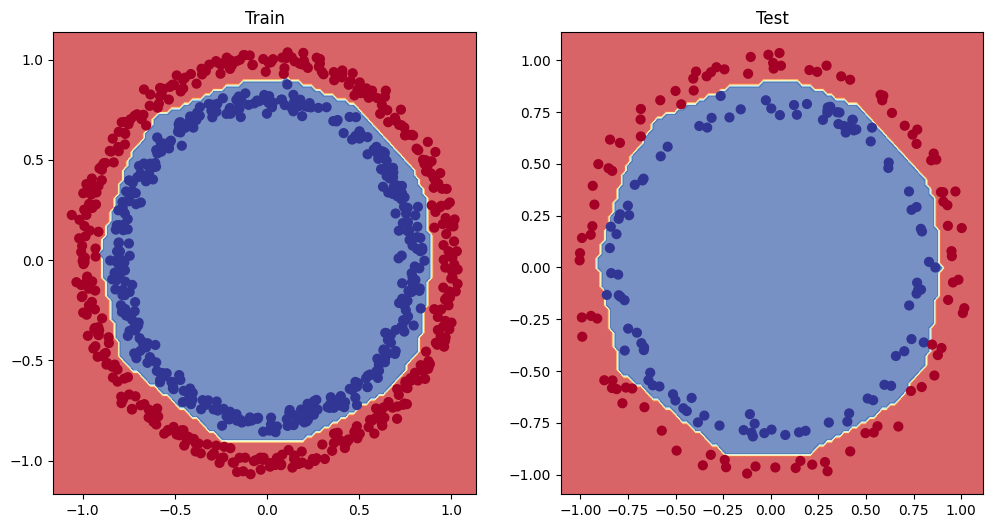

In [65]:
# Plot the decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

---

## 7. Replicating non-linear activation functions

Neural Networks, rather than us telling the model what to learn, we give it tools to discover patterns in data and it tries to figure out the patterns on its own.

And these tools are linear and non-linear functions.

In [66]:
# Create a tensor
A = torch.arange(-10, 10, 1, dtype = torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

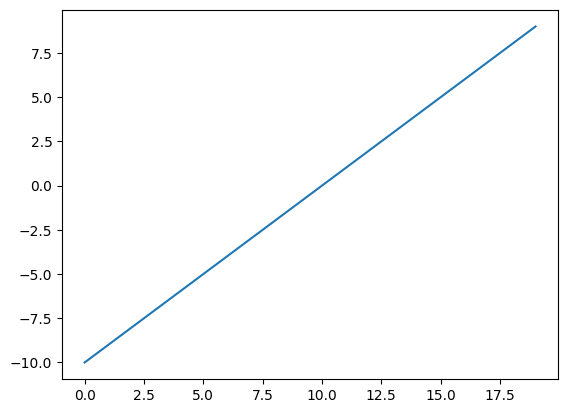

In [67]:
# Visualize the tensor
plt.plot(A);

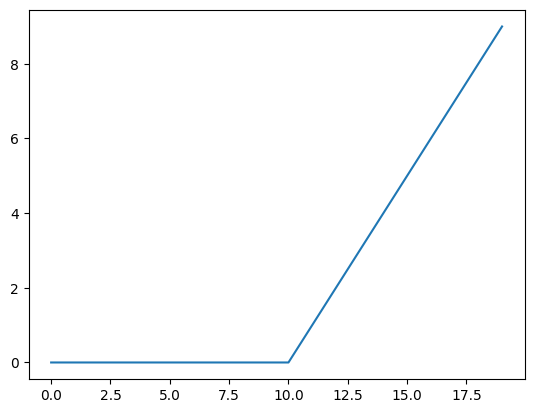

In [68]:
plt.plot(torch.relu(A));

In [69]:
def relu(x: torch.Tensor) -> torch.Tensor:
    return torch.max(torch.tensor(0), x) #inputs must be tensors

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

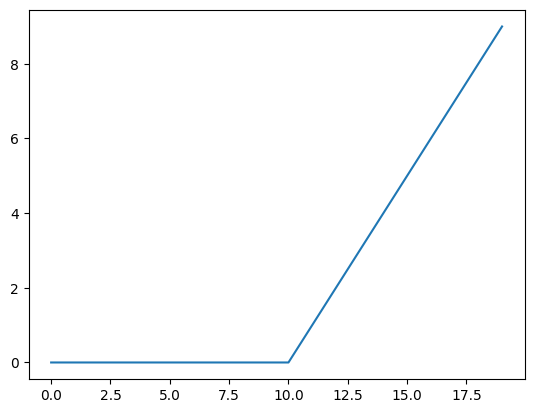

In [70]:
# Plot ReLU activation function
plt.plot(relu(A));

In [71]:
# Sigmoid
def sigmoid(x):
    return 1/(1 + (torch.exp(-x)))

sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

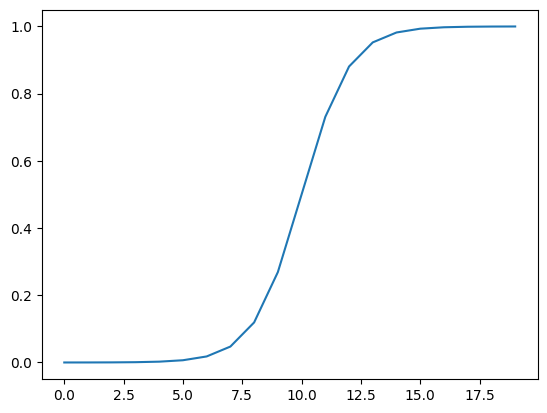

In [72]:
plt.plot(torch.sigmoid(A));

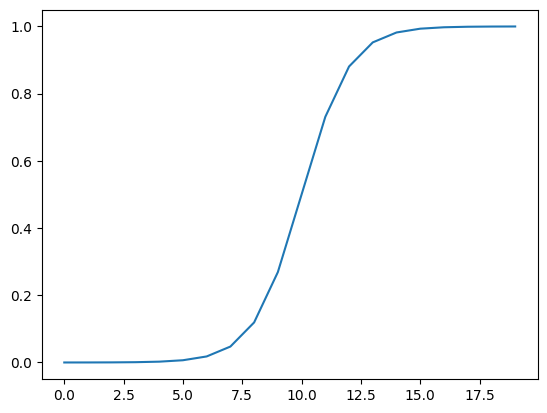

In [73]:
plt.plot(sigmoid(A));

----

### Exploding Gradients Vs Vanishing Gradients

During neural network backpropagation, gradients are calculated layer-by-layer moving backward from the output to the input. This relies on the **chain rule**, which repeatedly multiplies weights and activation derivatives(gradient) together.

The core math beavior follows a simple rule of exponentiation:
- Multiplying fractions repeatedly (0.5 x 0.5 x 0.5 ...) rapidly shrinks toward 0.
- Mulltiplying numbers greater than 1 repeatedly (2 x 2 x 2 ...) aggressively scales towards $\infty$.(instead of slowly finding the bottom of the loss hill, the weights jump completely off the map)

Comparison Matrix:

|                   | Vanishing Gradient                                             | Exploding Gradient                            |
|-------------------|----------------------------------------------------------------|-----------------------------------------------|
| Attribute         | Vanishing Gradient Problem                                     | Expoding Gradient Problem                     |
| Core Phenomenon   | Gradients become exponentially smaller as they travel backward | Gradients become exponentially larger as they travel backward|
| Mathematical Cause| Weights/derivatives are less than 1.0(e.g using Sigmoid or Tanh activations | Weights/derivatives are greater than 1.0 (e.g. poor weight initialization)|
| Symptoms during Training |* Loss Stops decreasing                                |* Loss fluctuates wildly or jumps to `Nan`/`Inf`|
|                          |* Early layers stop learning(weights stop updating)    |* Model becomes highly unstable                 |
|                          |* Model underfits                                      |* Weights overflow in memory                    |
| Architectures Affected   | Deep Feed Forward Networks,Vanilla RNNs               | Deep Networks with poor initialization, Vanilla RNNs|


* Primary Mitigations and Fixes:
 - For Vanishing Gradients:
   - `ReLU Activation`: Replace Sigmoid/Tanh with `torch.nn.ReLU()`. The derivative of ReLU for any positive input is exactly 1.0, preventing redction over depth.
   - `Residual(Skip) Connections`: Found in ResNets. They provide a direct pathway for gradients to bypass layers during backpropagation, preserving their magnitude.
   - `Batch Normalization`: Normalizes layer inputs to prevent activations from becoming saturated in dead zones.
 - For Exploding Gradients:
   - `Gradient Clipping`: Forces a maximum threshold on gradients before the optimizer updates the weights.(call before optimizer.step()) `torch.nn.utils.clip_grad_norm(model.parameters(), max_norm=1.0)`
   - `Weight Initialization(He/Xavier)`: These initialization methods use sppecific mathematical formulas to look at the number of inputs and outputs entering a layer(the channel sizes) and scale the random starting weights so their variance stays exactly at 1.0. This ensures that signals passing through the network don't artificially amplify or decay out of control.
   - `Gated Architectures`: LSTMs and GRUs introduce internal "gates"(like a forget gate and update gate). These gates use addition operations instead of purely multiplications to pass memory along. Because the math switches from multiplication to addition, the gradient has a stable path to travel backward wothout multiplying itself into infinity.
  


---

## 8. Multi-class Classification

* Binary classification = one thing or other (cat vs. dog, spam vs. not spam, fraud or not fraud)
* Multiclass class classification = more than one thing or another (cat vs. dog vs. chicken)

### 8.1 Creating a toy multi-class dataset

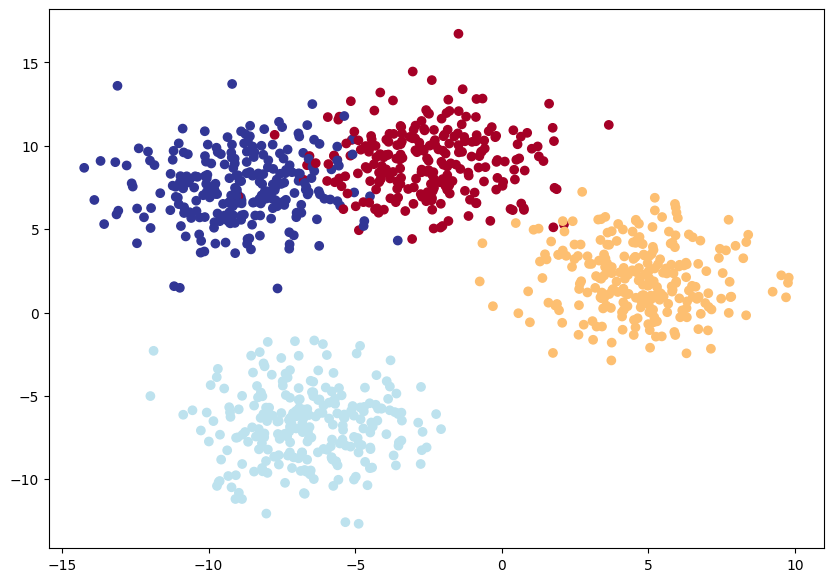

In [74]:
# make_blobs generates isotrophic Gaussian blobs (synthetic datasets where data points are grouped into distinct clusters, each centered
# around a specific mean with a defined standard deviation)

# Import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2 # 2D data for [x,y] cartesian plane
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples = 1000,
                            n_features = NUM_FEATURES,
                            centers = NUM_CLASSES, # no. of clusters
                            cluster_std = 2.0, # give the clusters a little shake up
                            random_state = RANDOM_SEED)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float32)
y_blob = torch.from_numpy(y_blob).type(torch.float32)
# y_blob = torch.from_numpy(y_blob).type(torch.LongTensor) is the right data type for multiclass classification

# 3. Split into train and test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size = 0.2,
                                                                        random_state = RANDOM_SEED)

# 4. Plot data(visualize)
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c = y_blob, cmap = plt.cm.RdYlBu);

# center_std: Standard Deviation for clusterd. It controls how scattered or "spread out" the points are around their respective cluster centres.
#    a low number like 0.5 means tight, dense and perfectly separated with massive empty gaps between them(easy task for model)
#    a higher number a spread out from further from their centers, causing the outer edges of the blobs to bleed(data leakage, seems good in
#             testing and validation but massively fails with real world data) and overlap each other.
# X_blob: 2D gris of coordinates(representing where the dot sitting on graph)
# y_blob: The integer labels of each data points which cluster it belongs to.(0 or 1 or 2 or 3)

### 8.2 Building a multi-class classification model in PyTorch

* The number of hidden layers can range from 1 to $\infty$(not technically but a lot)
* The number of neurons per layer generally ranges from 10 to 512
* Outfeatures for binary classification is 1 and 1 per class for multiclass classification
* Softmax activation function instead of Sigmoid for the mullticlass classification
* `torch.nn.CrossEntropy` instead of BCEWithLogitsLoss

In [75]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [76]:
# Build a multi-class classification model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units = 8):
        """Initializes multi-class classification model

        Args: 
            input_features(int): Number of input features
            output_features(int): Number of output features(number of output classes)
            hidden_units(int): Number of hidden units between layers, default 8
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            # nn.ReLU(),#even without non-linearity this model works 
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            # nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel(input_features = 2, #NUM_FEATURES
                    output_features = 4, #NUM_CLASSES
                    hidden_units = 8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [77]:
X_blob_train.shape, y_blob_train.shape

(torch.Size([800, 2]), torch.Size([800]))

In [78]:
y_blob_train.unique(), y_blob_train[:5]

(tensor([0., 1., 2., 3.]), tensor([1., 0., 2., 2., 0.]))

### 8.3 Create a loss function and an optimizer for a multi-class classification model

In [79]:
# Create a loss function for multi-class classification - loss function measures how wrong our model's predictions are
loss_fn = nn.CrossEntropyLoss()

# Create an Optimizer for multi-class classification - optimizer updates our model parameters to try and reduce the loss
optimizer = torch.optim.Adam(params = model_4.parameters(),
                            lr = 0.1)

### 8.4 Getting prediction probabilities for a multi-class PyTorch model

In order to evaluate, train and test our model, we need to convert our model's outputs(logits) to prediction probabilities and then to prediction labels.

Logits(raw output of the model) -> Pred Probs(use `torch.softmax`) -> Prediction Labels(take the argmax of the prediction probabilities)

In [80]:
# Let's get some raw outputs of our model (logits)
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test.to(device))

y_logits[:5], y_blob_test[:5] #we have to convert our logits to prediction labels

(tensor([[-1.3110, -0.9241, -1.5577, -0.5291],
         [ 1.6571, -1.2051,  1.6741,  2.0371],
         [ 2.2116,  0.8168,  2.5772,  0.9540],
         [-0.7035, -0.3389, -0.8034, -0.4880],
         [-0.6527, -1.6576, -0.9377,  0.5456]], device='cuda:0'),
 tensor([1., 3., 2., 1., 0.]))

In [81]:
# Convert our model's logits output to prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1) #dim 1 as classes are along different columns not along rows(different data points are along rows not classes)
y_logits[:5], y_pred_probs[:5]

(tensor([[-1.3110, -0.9241, -1.5577, -0.5291],
         [ 1.6571, -1.2051,  1.6741,  2.0371],
         [ 2.2116,  0.8168,  2.5772,  0.9540],
         [-0.7035, -0.3389, -0.8034, -0.4880],
         [-0.6527, -1.6576, -0.9377,  0.5456]], device='cuda:0'),
 tensor([[0.1838, 0.2707, 0.1437, 0.4018],
         [0.2828, 0.0162, 0.2876, 0.4135],
         [0.3363, 0.0834, 0.4847, 0.0956],
         [0.2181, 0.3140, 0.1973, 0.2705],
         [0.1841, 0.0674, 0.1384, 0.6101]], device='cuda:0'))

In [82]:
torch.sum(y_pred_probs[0]), torch.max(y_pred_probs[0])

(tensor(1., device='cuda:0'), tensor(0.4018, device='cuda:0'))

In [83]:
# Convert our model's prediction probabilities into prediction labels
y_pred_labels = torch.argmax(y_pred_probs, dim=1)
y_pred_labels[:50]

tensor([3, 3, 2, 1, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 3, 3, 2, 2,
        2, 2, 3, 3, 3, 3, 3, 3, 1, 2, 1, 2, 1, 3, 3, 2, 3, 2, 3, 2, 3, 3, 3, 3,
        3, 3], device='cuda:0')

### 8.5 Creating a trianing loop and testing loop for a multi-class PyTorch model

In [84]:
import torch

In [85]:
## Training and Testing loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# device agnostic code
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device).long() 
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device).long()
# multiclass cross entropy requirement and as we converted X_blob and y_blob to float this will not work as prediction lables need to be 3 not 3.0 
# so .long() changes type to int64 or change y=

# Set number of epochs
epochs = 200

for epoch in range(epochs):
    ## Training
    model_4.train()
    
    #1. Forward Pass
    y_blob_logits = model_4(X_blob_train)
    y_blob_pred = torch.softmax(y_blob_logits, dim = 1).argmax(dim = 1)

    #2. Calculate the loss/acc
    loss = loss_fn(y_blob_logits, y_blob_train)
    acc = accuracy_fn(y_true = y_blob_train,
                     y_pred = y_blob_pred)

    #3. Optimizer zero grad
    optimizer.zero_grad()

    #4. Loss Backward()
    loss.backward()

    #5. Optimizer Step
    optimizer.step()

    ## Testing
    model_4.eval()
    with torch.inference_mode():
        #1. Forward Pass
        test_blob_logits = model_4(X_blob_test)
        test_blob_pred = torch.softmax(test_blob_logits, dim = 1).argmax(dim = 1)

        #2. Calculate the test loss/acc
        test_loss = loss_fn(test_blob_logits, y_blob_test)
        test_acc = accuracy_fn(y_true = y_blob_test,
                         y_pred = test_blob_pred)

    ## Print out what's happening
    if epoch % 10 == 0:
        print(f"epoch: {epoch} | loss: {loss:.4f}, accuracy: {acc:.2f}% | test_loss: {test_loss:.4f}, test_acc: {test_acc:.2f}%")

epoch: 0 | loss: 1.0519, accuracy: 63.00% | test_loss: 0.6216, test_acc: 73.50%
epoch: 10 | loss: 0.1771, accuracy: 94.12% | test_loss: 0.0671, test_acc: 97.50%
epoch: 20 | loss: 0.0950, accuracy: 96.25% | test_loss: 0.0879, test_acc: 96.50%
epoch: 30 | loss: 0.0811, accuracy: 96.75% | test_loss: 0.0472, test_acc: 98.50%
epoch: 40 | loss: 0.0745, accuracy: 97.00% | test_loss: 0.0512, test_acc: 98.00%
epoch: 50 | loss: 0.0720, accuracy: 96.88% | test_loss: 0.0447, test_acc: 98.00%
epoch: 60 | loss: 0.0710, accuracy: 97.38% | test_loss: 0.0473, test_acc: 97.50%
epoch: 70 | loss: 0.0707, accuracy: 97.25% | test_loss: 0.0478, test_acc: 97.50%
epoch: 80 | loss: 0.0706, accuracy: 97.12% | test_loss: 0.0458, test_acc: 97.50%
epoch: 90 | loss: 0.0705, accuracy: 97.12% | test_loss: 0.0458, test_acc: 97.50%
epoch: 100 | loss: 0.0705, accuracy: 97.12% | test_loss: 0.0466, test_acc: 97.50%
epoch: 110 | loss: 0.0705, accuracy: 97.12% | test_loss: 0.0462, test_acc: 97.50%
epoch: 120 | loss: 0.0705, 

### 8.6 Making and evaluating predictions with a PyTorch multi-class model

In [86]:
# Make Predictions
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)
    y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1) # logits -> pred probs -> pred labels
y_preds[:5], y_blob_test[:5]

(tensor([1, 3, 2, 1, 0], device='cuda:0'),
 tensor([1, 3, 2, 1, 0], device='cuda:0'))

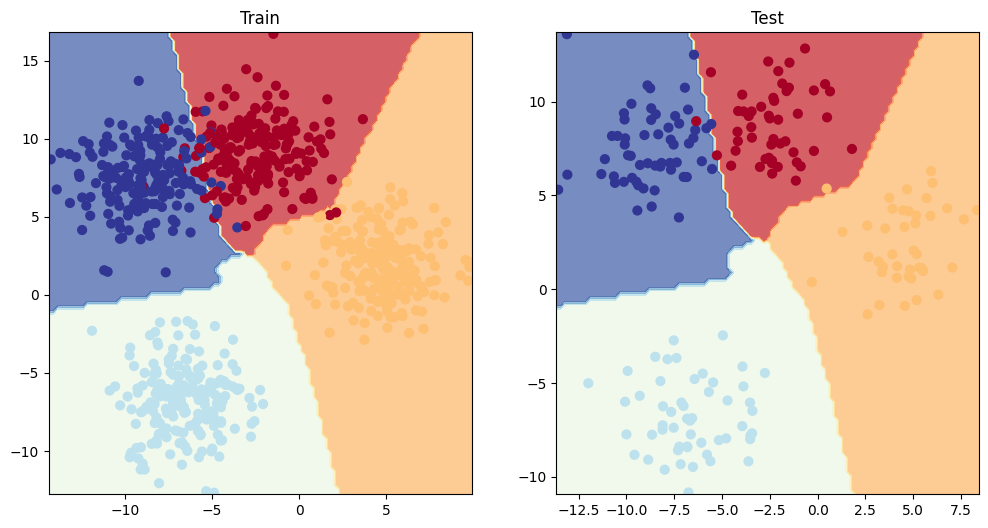

In [115]:
# Plot the decision boundary(non - linear layers plot)
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

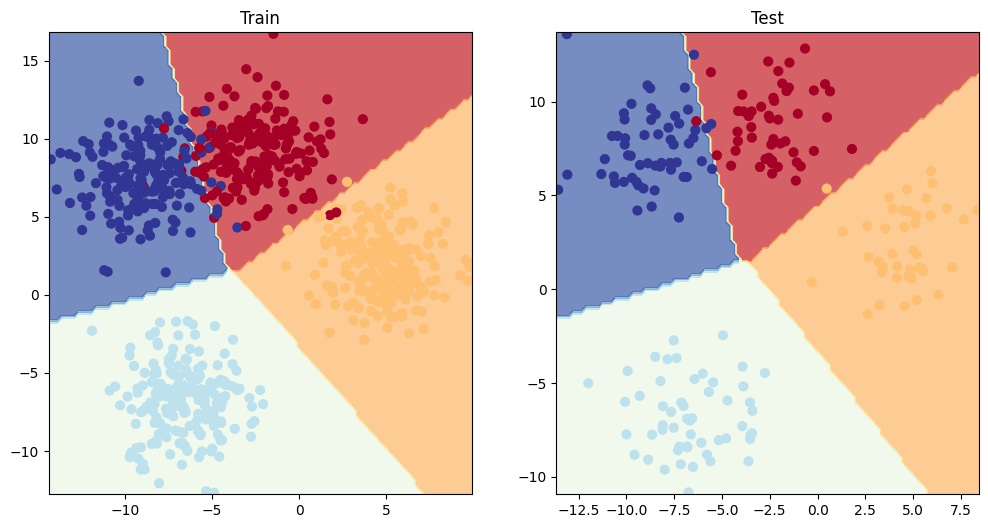

In [88]:
# Plot the decision boundary(linear layers plot)
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

---

## 9. A few more classification metrics...(to evaluate our classificaton model)

* Accuracy - out of n samples, how many does our model gets right? - `torchmetrics.Accuracy()` or `sklearn.metrics.accuracy_score` - Default metric for classification problems. Not the best for imbalanced classes.
* Precision -- `torchmetrics.Precision()` or `sklearn.metrics.precision_score` - Higher precision leads to less false positives.
* Recall -- `torchmetrics.Recall()` or `sklearn.metrics.recall_score` - Higher recall leads to less false negatives.
* F1-Score -- `torchmetrics.F1Score()` or `sklearn.metrics.f1_score()` - Combination of precision and recall, usually a good overall metric for a classification model.
* Confusion Matrix -- `torchmetrics.ConnfusionMatrix()` - When comparing predictions to truth labels to see where model gets confused. Can be hard to use with large number of classes.
* Classification Matrix -- `sklearn.metrics.classification_report` - Builds a text report showing the main classification metrics.


- precision inversely proportional to recall so precision recall tradeoff used.

In [89]:
# https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQiikSNzE_TmOTToYk_RUQxa6KUmnKElHZTJ9Lm24WbfA5ZHJfPZeGNzN0&s=10
# the above one is the confusion matrix image link

### Evaluation Metrices

`1. The Foundation: The Confusion Matrix`: It is a cross-table layout that compares our model's predictions against the actual real world truth.

  * **True Positive(TP)**: The model predicted Yes, and the actual truth was Yes(e.g predicted apple, was a apple)
  * **True Negative(TN)**: The model predicted No, and the actual truth was No(e.g predicted not apple, wasn't apple/was orange)
  * **False Positive(FP)**: The model predicted Yes, but the actual truth was No(A false alarm)
  * **False Negative(FN)**: The model ppredicted No, but the actual truth was Yes(A dangerous miss)

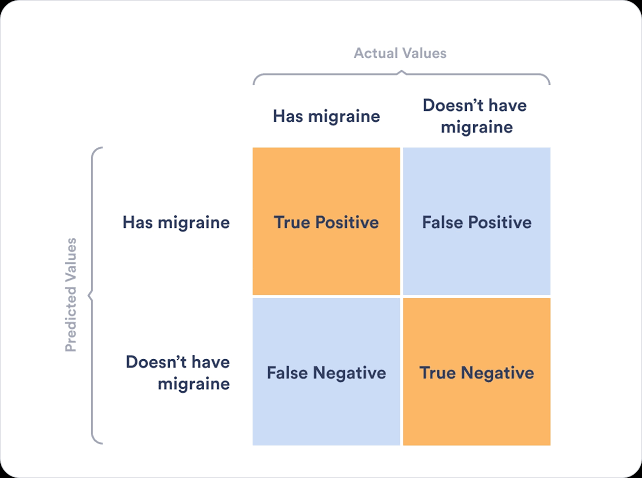

`2. Core Evaluation Metrics`: Using terms from the confusion matrix we can calculate the core scores.

* `Accuracy`: The percentage of total predictions the model got exactly got right
  $$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$$

  - When to use: When the dataset is evenly balanced only(e.g 50% dogs and 50% cats)
  - When to avoid: Imbalanced datasets

* `Precision`: Out of all the items claimed were positive, how many are actually positive?
$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

  - When it matters: When False Positives are expensive. For example, a spam filter. If a normal emai is flagged as spam(False Positive), we might miss an important work message. Here we want high precision
 
* `Recall(Sensitivity)`: Out of all items that were positive in the real world, how many did the model manage to find?
$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

  - When it matters: When False Negatives are dangerous. For example, in cancer detection if a patient has cancer but the model misses it(False Negative), the patient goes untreated. We want high recall, even it means causing a few false alarms.

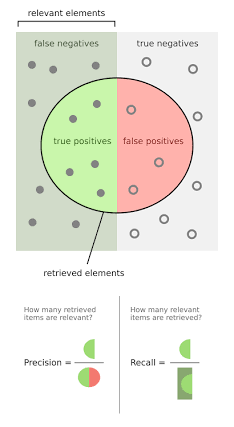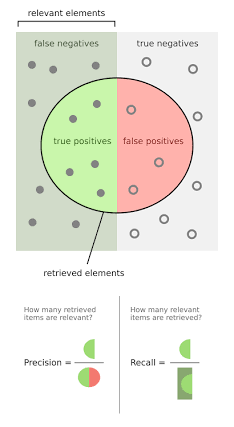

Precision Vs Recall Visually


* `F1-Score`: The Harmonic mean of Precsion and Recall. It balances both metrics into a single number. If either our precision or recall is terrible, our F1-Score collapses.
$$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

  - When to use: This is our primary metric when we're dealing with heavily imbalanced datasets and need a reliable indicator of overall model health.
 

`3. Advanced Comparision Tools`:

* `Classification Report(Classification Matrix)`: This isnt a standalone mathematical formula, its a disgnostic text summary printout provided by libraries like Scikit-Learn. It automatically calculates the Precision, Recall, and F1-Score for every single individual class in our dataset, showing exactly where our model is struggling.

* `AUC-ROC Curve`:
  - `ROC(Receiver Operating Characteristic) Curve`: A graph showing how our model performs at every possible decision threshold(from 0 to 1). It plots the True Positive Rate(Recall) on the vertical axis against the False Positive Rate on the horizontal axis.
 $$\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$$
  - `AUC(Area Under the Curve)`: A single score between `0.0` and `1.0` representing the total area under the drawn line.
    - An AUC of 1.0 means a perfect model
    - An AUC of 0.5 means our model is completely useless and performs no better than flipping a random coin


$$\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$$
$$\text{TPR/Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$
$$\text{TN} = {\text{TN} - \text{FP}}$$
$$\text{FNR} = \frac{\text{FN}}{\text{TP} + \text{FN}} = 1−Sensitivity$$
$$\text{FNR} = \frac{\text{TN}}{\text{TN} + \text{FP}}$$

In [90]:
import torchmetrics

In [91]:
from torchmetrics import Accuracy

# Setup metric
torchmetric_accuracy = Accuracy(task="multiclass", num_classes=4).to(device)

# Calculate accuracy
model_accuracy = torchmetric_accuracy(y_preds, y_blob_test)
print(f"model_accuracy: {model_accuracy*100:.2f}%")

model_accuracy: 97.50%


In [92]:
import torch
from torchmetrics import Accuracy, Precision, Recall, AUROC, ConfusionMatrix, F1Score

# 1. Generate claean prdictions and raw logits from our model
# model_4.eval()
# with torch.inference_mode():
#     y_logits = model_4(X_blob_test.to(device))
#     y_pred_probs = torch.softmax(y_logits, dim=1)
#     y_preds = torch.argmax(y_pred_probs, dim=1)

# 2. Instiantiate metrics properly with correct tasks
torchmetric_precision = Precision(task="multiclass", num_classes=4).to(device)
torchmetric_recall = Recall(task="multiclass", num_classes=4).to(device)
torchmetric_f1score = F1Score(task="multiclass", num_classes=4).to(device)
torchmetric_confusionmatrix = ConfusionMatrix(task="multiclass", num_classes=4).to(device)
torchmetric_auroc = AUROC(task="multiclass", num_classes=4).to(device)

# 3. Calculate the scores
precision = torchmetric_precision(y_preds, y_blob_test.to(device))
recall = torchmetric_recall(y_preds, y_blob_test.to(device))
f1 = torchmetric_f1score(y_preds, y_blob_test.to(device))
conf_matrix = torchmetric_confusionmatrix(y_preds, y_blob_test.to(device))
auroc = torchmetric_auroc(y_pred_probs, y_blob_test.to(device))

# 4. Print results
print(f"TorchMetrics - Precision: {precision*100:.2f}%")
print(f"TorchMetrics - Recall:    {recall*100:.2f}%")
print(f"TorchMetrics - F1-Score:  {f1*100:.2f}%")
print(f"TorchMetrics - AUROC:     {auroc*100:.2f}%")
print("\nTorchMetrics Confusion Matrix:\n", conf_matrix)

TorchMetrics - Precision: 97.50%
TorchMetrics - Recall:    97.50%
TorchMetrics - F1-Score:  97.50%
TorchMetrics - AUROC:     73.00%

TorchMetrics Confusion Matrix:
 tensor([[48,  0,  0,  1],
        [ 1, 40,  0,  0],
        [ 0,  0, 53,  0],
        [ 3,  0,  0, 54]], device='cuda:0')


In [93]:
# SKLEARN CODE FOR METRICS SAME AS ABOVE
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix, 
    classification_report
)

# 1. Bring your GPU data back down to standard CPU NumPy arrays
# (Using the y_preds and y_pred_probs variables generated in the step above)
y_true_np = y_blob_test.cpu().numpy()
y_pred_np = y_preds.cpu().numpy()
y_prob_np = y_pred_probs.cpu().numpy()

# 2. Calculate the standard scores
sk_accuracy = accuracy_score(y_true_np, y_pred_np)
sk_precision = precision_score(y_true_np, y_pred_np, average="macro") # 'macro' calculates metrics globally per class
sk_recall = recall_score(y_true_np, y_pred_np, average="macro")
sk_f1 = f1_score(y_true_np, y_pred_np, average="macro")
sk_conf_matrix = confusion_matrix(y_true_np, y_pred_np)

# Multi-class AUROC requires 'ovr' (One-vs-Rest) strategy and probability shapes
sk_auroc = roc_auc_score(y_true_np, y_prob_np, multi_class="ovr") 

# 3. Print individual metrics
print(f"scikit-learn - Accuracy:  {sk_accuracy*100:.2f}%")
print(f"scikit-learn - Precision: {sk_precision*100:.2f}%")
print(f"scikit-learn - Recall:    {sk_recall*100:.2f}%")
print(f"scikit-learn - F1-Score:  {sk_f1*100:.2f}%")
print(f"scikit-learn - AUROC:     {sk_auroc*100:.2f}%")
print("\nscikit-learn Confusion Matrix:\n", sk_conf_matrix)

# 4. The Comprehensive Alternative: Print the full Classification Matrix Report
print("\n--- Full Scikit-Learn Classification Report ---")
print(classification_report(y_true_np, y_pred_np))

scikit-learn - Accuracy:  97.50%
scikit-learn - Precision: 97.62%
scikit-learn - Recall:    97.56%
scikit-learn - F1-Score:  97.56%
scikit-learn - AUROC:     73.00%

scikit-learn Confusion Matrix:
 [[48  0  0  1]
 [ 1 40  0  0]
 [ 0  0 53  0]
 [ 3  0  0 54]]

--- Full Scikit-Learn Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        49
           1       1.00      0.98      0.99        41
           2       1.00      1.00      1.00        53
           3       0.98      0.95      0.96        57

    accuracy                           0.97       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.97      0.98       200

